# 📱 LG Gram Reddit API Data Mining & Sentiment Analysis

## 프로젝트 개요
Reddit API를 활용하여 LG Gram 노트북에 대한 사용자 의견을 수집하고 분석하는 프로젝트입니다.

### 주요 목표
1. **데이터 수집**: Reddit에서 LG Gram 관련 포스트 및 댓글 수집
2. **감성 분석**: 긍정/부정/중립 감정 분석
3. **토픽 분석**: 주요 논의 주제 및 키워드 추출
4. **장단점 분석**: Pros & Cons 자동 추출
5. **시각화**: 워드클라우드, 감성 분포, 주요 키워드 등

### 분석 과정
1. 환경 설정 및 라이브러리 설치
2. Reddit API 연결 설정
3. 데이터 크롤링 및 수집
4. 데이터 전처리 및 정제
5. 감성 분석 및 토픽 모델링
6. 시각화 및 인사이트 도출

### 주의사항
- Reddit API 이용약관 및 Rate Limit 준수
- 개인정보 보호 및 윤리적 데이터 사용

In [1]:
# 1. 필수 라이브러리 설치 및 임포트
import sys
import subprocess
import importlib
import os

# 필요한 패키지 목록
required_packages = [
    'praw',           # Reddit API
    'pandas',         # 데이터 처리
    'numpy',          # 수치 계산
    'matplotlib',     # 시각화
    'seaborn',        # 고급 시각화
    'wordcloud',      # 워드클라우드
    'konlpy',         # 한국어 자연어 처리
    'tqdm',           # 진행 표시줄
    'textblob',       # 감성 분석
    'python-dotenv',  # 환경변수 관리
    'scikit-learn'    # 머신러닝
]

# 패키지 설치 함수
def install_packages(packages):
    for package in packages:
        try:
            # python-dotenv는 dotenv로 임포트
            import_name = 'dotenv' if package == 'python-dotenv' else package
            importlib.import_module(import_name)
            print(f"✅ {package} 이미 설치됨")
        except ImportError:
            print(f"📦 {package} 설치 중...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
            print(f"✅ {package} 설치 완료")

# 패키지 설치 실행
install_packages(required_packages)

# 라이브러리 임포트
import pandas as pd
import numpy as np
import re
import time
import json
import itertools
from pathlib import Path
from datetime import datetime
from collections import Counter
from dataclasses import dataclass, asdict

import praw
from tqdm import tqdm
from textblob import TextBlob
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🎉 모든 라이브러리 설치 및 임포트 완료!")

✅ praw 이미 설치됨
✅ pandas 이미 설치됨
✅ numpy 이미 설치됨
✅ matplotlib 이미 설치됨
✅ pandas 이미 설치됨
✅ numpy 이미 설치됨
✅ matplotlib 이미 설치됨
✅ seaborn 이미 설치됨
✅ wordcloud 이미 설치됨
✅ konlpy 이미 설치됨
✅ tqdm 이미 설치됨
✅ seaborn 이미 설치됨
✅ wordcloud 이미 설치됨
✅ konlpy 이미 설치됨
✅ tqdm 이미 설치됨
✅ textblob 이미 설치됨
✅ python-dotenv 이미 설치됨
📦 scikit-learn 설치 중...
✅ textblob 이미 설치됨
✅ python-dotenv 이미 설치됨
📦 scikit-learn 설치 중...
✅ scikit-learn 설치 완료
🎉 모든 라이브러리 설치 및 임포트 완료!
✅ scikit-learn 설치 완료
🎉 모든 라이브러리 설치 및 임포트 완료!


In [2]:
# 2. 환경 설정 및 Reddit API 설정

# 환경변수 로드
load_dotenv()

# 필수 환경변수 확인
REQUIRED_ENV_VARS = ['REDDIT_CLIENT_ID', 'REDDIT_CLIENT_SECRET', 'REDDIT_USER_AGENT']
missing_vars = [var for var in REQUIRED_ENV_VARS if not os.getenv(var)]

if missing_vars:
    print("⚠️  다음 환경변수가 설정되지 않았습니다:")
    for var in missing_vars:
        print(f"   - {var}")
    print("\n📝 .env 파일을 생성하고 다음 내용을 추가해주세요:")
    print("REDDIT_CLIENT_ID=your_client_id")
    print("REDDIT_CLIENT_SECRET=your_client_secret") 
    print("REDDIT_USER_AGENT=your_app_name/1.0 by your_username")
    print("\n🔗 Reddit API 키 발급: https://www.reddit.com/prefs/apps")
else:
    print("✅ Reddit API 환경변수 설정 완료")

# 데이터 저장 디렉토리 설정
PROJECT_DIR = Path('data/lg_gram_reddit')
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = PROJECT_DIR / 'analysis'
ANALYSIS_DIR.mkdir(exist_ok=True)

IMAGES_DIR = PROJECT_DIR / 'images'
IMAGES_DIR.mkdir(exist_ok=True)

# 파일 경로 설정
RAW_DATA_FILE = PROJECT_DIR / 'reddit_lg_gram_posts.csv'
PROCESSED_DATA_FILE = ANALYSIS_DIR / 'lg_gram_processed.csv'
PROS_FILE = ANALYSIS_DIR / 'pros_analysis.csv'
CONS_FILE = ANALYSIS_DIR / 'cons_analysis.csv'

print(f"📁 데이터 저장 경로: {PROJECT_DIR}")
print(f"📊 분석 결과 경로: {ANALYSIS_DIR}")
print(f"🖼️  이미지 저장 경로: {IMAGES_DIR}")

# Reddit 클라이언트 초기화 함수
def initialize_reddit_client():
    """Reddit API 클라이언트 초기화"""
    if any(not os.getenv(var) for var in REQUIRED_ENV_VARS):
        raise EnvironmentError("Reddit API 환경변수가 설정되지 않았습니다.")
    
    return praw.Reddit(
        client_id=os.getenv('REDDIT_CLIENT_ID'),
        client_secret=os.getenv('REDDIT_CLIENT_SECRET'),
        user_agent=os.getenv('REDDIT_USER_AGENT'),
    )

print("🚀 환경 설정 완료!")

✅ Reddit API 환경변수 설정 완료
📁 데이터 저장 경로: data\lg_gram_reddit
📊 분석 결과 경로: data\lg_gram_reddit\analysis
🖼️  이미지 저장 경로: data\lg_gram_reddit\images
🚀 환경 설정 완료!


In [3]:
# 3. 데이터 모델 및 크롤링 설정

# 데이터 구조 정의
@dataclass
class LGGramPost:
    """LG Gram 관련 Reddit 포스트 데이터 모델"""
    id: str
    subreddit: str
    title: str
    selftext: str
    created_utc: float
    score: int
    num_comments: int
    permalink: str
    url: str
    combined_text: str
    author: str = ""

# 타겟 서브레딧 설정 (LG Gram 관련)
TARGET_SUBREDDITS = [
    'LGgram',           # LG Gram 전용 서브레딧
    'lglaptops',        # LG 노트북 일반
    'laptops',          # 노트북 일반 토론
    'SuggestALaptop',   # 노트북 추천
    'hardware',         # 하드웨어 리뷰
    'ultrabooks',       # 울트라북 관련
    'LaptopDeals',      # 노트북 딜 정보
    'techsupport',      # 기술 지원
    'BuyItForLife'      # 내구성 제품 토론
]

# 검색 키워드 설정
BASE_KEYWORDS = [
    'lg gram',
    'lg gram 2024',
    'lg gram 2025', 
    'lg gram 17',
    'lg gram 16',
    'lg gram 15',
    'lg gram 14',
    'lg gram review',
    'lg gram ultralight',
    'lg gram laptop'
]

# 성능/이슈 관련 키워드 (영어)
PERFORMANCE_KEYWORDS_EN = [
    'performance', 'slow', 'lag', 'throttle', 'thermal throttling',
    'overheating', 'heat', 'fan noise', 'battery drain', 'battery life',
    'weak gpu', 'integrated graphics', 'gaming performance',
    'ram upgrade', 'ssd speed', 'hinge issue', 'keyboard flex',
    'build quality', 'durability', 'screen wobble'
]

# 성능/이슈 관련 키워드 (한국어)
PERFORMANCE_KEYWORDS_KO = [
    '성능', '느림', '버벅', '발열', '과열', '팬소음', '배터리 소모',
    '업그레이드', '램 업그레이드', '힌지 문제', '키보드 문제',
    '내구성', '플렉스'
]

# 감정 분석 키워드
NEGATIVE_KEYWORDS = [
    'issue', 'problem', 'cons', 'drawbacks', 'weakness', 'complaint',
    'bad', 'worse', 'disappointed', 'annoying'
]

# 전체 검색 키워드 생성
def generate_search_keywords():
    """검색 키워드 조합 생성"""
    keywords = set(BASE_KEYWORDS)
    
    # 베이스 키워드 + 성능 키워드 조합
    for base in BASE_KEYWORDS[:5]:  # 너무 많아지지 않도록 제한
        for perf in PERFORMANCE_KEYWORDS_EN[:10]:
            keywords.add(f"{base} {perf}")
        for perf in PERFORMANCE_KEYWORDS_KO[:5]:
            keywords.add(f"{base} {perf}")
        for neg in NEGATIVE_KEYWORDS[:5]:
            keywords.add(f"{base} {neg}")
    
    return list(keywords)

SEARCH_KEYWORDS = generate_search_keywords()

# 크롤링 설정
CRAWLING_CONFIG = {
    'use_crawling': True,        # False로 설정하면 기존 데이터 사용
    'limit_per_query': 50,       # 쿼리당 최대 포스트 수
    'sleep_interval': 0.8,       # API 호출 간 대기 시간 (초)
    'max_keywords': 100,         # 최대 키워드 수 제한
    'sort_method': 'new'         # 정렬 방식 (new, hot, top)
}

print(f"🎯 타겟 서브레딧: {len(TARGET_SUBREDDITS)}개")
print(f"🔍 검색 키워드: {len(SEARCH_KEYWORDS)}개 (상한: {CRAWLING_CONFIG['max_keywords']})")
print(f"📊 예상 총 검색 쿼리: {len(TARGET_SUBREDDITS) * min(len(SEARCH_KEYWORDS), CRAWLING_CONFIG['max_keywords'])}")
print("⚙️  크롤링 설정 완료!")

🎯 타겟 서브레딧: 9개
🔍 검색 키워드: 110개 (상한: 100)
📊 예상 총 검색 쿼리: 900
⚙️  크롤링 설정 완료!


In [4]:
# 4. Reddit 데이터 크롤링 실행

def crawl_reddit_data():
    """Reddit에서 LG Gram 관련 데이터 크롤링"""
    posts = []
    
    if not CRAWLING_CONFIG['use_crawling']:
        print("⏭️  크롤링 비활성화 - 기존 데이터 사용")
        return posts
    
    try:
        # Reddit 클라이언트 초기화
        reddit = initialize_reddit_client()
        seen_ids = set()
        
        # 키워드 수 제한
        limited_keywords = SEARCH_KEYWORDS[:CRAWLING_CONFIG['max_keywords']]
        total_queries = len(TARGET_SUBREDDITS) * len(limited_keywords)
        
        print(f"🚀 크롤링 시작: {total_queries}개 쿼리 예정")
        print(f"⏱️  예상 소요 시간: {total_queries * CRAWLING_CONFIG['sleep_interval'] / 60:.1f}분")
        
        query_count = 0
        
        # 서브레딧별로 크롤링
        for subreddit_name in TARGET_SUBREDDITS:
            print(f"\n📂 처리 중: r/{subreddit_name}")
            
            try:
                subreddit = reddit.subreddit(subreddit_name)
            except Exception as e:
                print(f"❌ 서브레딧 접근 실패: {e}")
                continue
            
            # 키워드별로 검색
            for keyword in limited_keywords:
                query_count += 1
                
                try:
                    # 검색 실행
                    search_results = subreddit.search(
                        keyword, 
                        limit=CRAWLING_CONFIG['limit_per_query'],
                        sort=CRAWLING_CONFIG['sort_method']
                    )
                    
                    # 결과 처리
                    for submission in search_results:
                        if submission.id in seen_ids:
                            continue
                        
                        # 포스트 데이터 추출
                        post_data = LGGramPost(
                            id=submission.id,
                            subreddit=subreddit_name,
                            title=submission.title.strip(),
                            selftext=getattr(submission, 'selftext', '') or '',
                            created_utc=float(getattr(submission, 'created_utc', 0.0)),
                            score=int(getattr(submission, 'score', 0)),
                            num_comments=int(getattr(submission, 'num_comments', 0)),
                            permalink=f'https://reddit.com{submission.permalink}',
                            url=getattr(submission, 'url', ''),
                            combined_text=(submission.title + '\n' + (getattr(submission, 'selftext', '') or '')).strip(),
                            author=str(getattr(submission, 'author', ''))
                        )
                        
                        posts.append(post_data)
                        seen_ids.add(submission.id)
                
                except Exception as e:
                    if 'RATELIMIT' in str(e).upper():
                        print(f"⏳ Rate limit 도달 - 10초 대기: {e}")
                        time.sleep(10)
                    else:
                        if query_count % 50 == 0:
                            print(f"⚠️  검색 오류 ({keyword[:30]}...): {e}")
                
                # 진행상황 출력
                if query_count % 20 == 0:
                    print(f"📊 진행률: {query_count}/{total_queries} ({query_count/total_queries*100:.1f}%) | 수집: {len(posts)}개")
                
                # API 호출 간 대기
                time.sleep(CRAWLING_CONFIG['sleep_interval'])
        
        print(f"\n✅ 크롤링 완료! 총 {len(posts)}개 포스트 수집")
        
    except Exception as e:
        print(f"❌ 크롤링 중 오류 발생: {e}")
    
    return posts

# 크롤링 실행
collected_posts = crawl_reddit_data()

# 데이터프레임 생성 및 저장
if collected_posts:
    # 데이터프레임 생성
    df_raw = pd.DataFrame([asdict(post) for post in collected_posts])
    
    # 중복 제거 (같은 ID)
    df_raw = df_raw.drop_duplicates(subset='id')
    
    # 날짜 컬럼 추가
    df_raw['created_date'] = pd.to_datetime(df_raw['created_utc'], unit='s')
    
    # 원본 데이터 저장
    df_raw.to_csv(RAW_DATA_FILE, index=False, encoding='utf-8-sig')
    
    print(f"💾 원본 데이터 저장: {RAW_DATA_FILE}")
    print(f"📈 최종 수집 데이터: {len(df_raw)}개")
    
elif RAW_DATA_FILE.exists():
    # 기존 파일 로드
    df_raw = pd.read_csv(RAW_DATA_FILE)
    df_raw['created_date'] = pd.to_datetime(df_raw['created_utc'], unit='s')
    print(f"📂 기존 데이터 로드: {len(df_raw)}개")
    
else:
    # 빈 데이터프레임 생성
    df_raw = pd.DataFrame(columns=['id', 'subreddit', 'title', 'selftext', 'combined_text'])
    print("⚠️  수집된 데이터가 없습니다.")

# 기본 정보 출력
if not df_raw.empty:
    print(f"\n📊 데이터 기본 정보:")
    print(f"   - 총 포스트 수: {len(df_raw)}")
    print(f"   - 서브레딧 수: {df_raw['subreddit'].nunique()}")
    print(f"   - 평균 점수: {df_raw['score'].mean():.1f}")
    print(f"   - 평균 댓글 수: {df_raw['num_comments'].mean():.1f}")
    
    # 상위 3개 샘플 출력
    print(f"\n📝 수집 데이터 샘플:")
    display(df_raw[['subreddit', 'title', 'score', 'num_comments', 'created_date']].head(3))

🚀 크롤링 시작: 900개 쿼리 예정
⏱️  예상 소요 시간: 12.0분

📂 처리 중: r/LGgram
📊 진행률: 20/900 (2.2%) | 수집: 55개
📊 진행률: 20/900 (2.2%) | 수집: 55개
📊 진행률: 40/900 (4.4%) | 수집: 56개
📊 진행률: 40/900 (4.4%) | 수집: 56개
📊 진행률: 60/900 (6.7%) | 수집: 56개
📊 진행률: 60/900 (6.7%) | 수집: 56개
📊 진행률: 80/900 (8.9%) | 수집: 56개
📊 진행률: 80/900 (8.9%) | 수집: 56개
📊 진행률: 100/900 (11.1%) | 수집: 56개
📊 진행률: 100/900 (11.1%) | 수집: 56개

📂 처리 중: r/lglaptops

📂 처리 중: r/lglaptops
📊 진행률: 120/900 (13.3%) | 수집: 56개
📊 진행률: 120/900 (13.3%) | 수집: 56개
📊 진행률: 140/900 (15.6%) | 수집: 56개
📊 진행률: 140/900 (15.6%) | 수집: 56개
⚠️  검색 오류 (lg gram 2025 battery drain...): Redirect to /subreddits/search
⚠️  검색 오류 (lg gram 2025 battery drain...): Redirect to /subreddits/search
📊 진행률: 160/900 (17.8%) | 수집: 56개
📊 진행률: 160/900 (17.8%) | 수집: 56개
📊 진행률: 180/900 (20.0%) | 수집: 56개
📊 진행률: 180/900 (20.0%) | 수집: 56개
⚠️  검색 오류 (lg gram 2025 battery life...): Redirect to /subreddits/search
📊 진행률: 200/900 (22.2%) | 수집: 56개
⚠️  검색 오류 (lg gram 2025 battery life...): Redirect to /subreddits/s

,subreddit,title,score,num_comments,created_date
0,LGgram,Which LG gram modes fare the best in terms of ...,1,3,2025-08-16 17:06:09
1,LGgram,Dock / Hub Considerations for 17 Gram?,1,3,2025-08-13 05:41:53
2,LGgram,LG GRAM 17Z90R-H.AAC8U1 144hz question,1,6,2025-08-09 05:49:37


In [5]:
# 5. 데이터 전처리 및 토큰화

# 전처리 함수 정의
def clean_text(text):
    """텍스트 전처리"""
    if pd.isna(text) or text == '':
        return ''
    
    # 소문자 변환
    text = str(text).lower()
    
    # 특수 문자 제거 (한글, 영어, 숫자, 공백만 유지)
    text = re.sub(r'[^0-9A-Za-z가-힣\s]', ' ', text)
    
    # 연속된 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# 불용어 정의
ENGLISH_STOPWORDS = {
    'the', 'a', 'an', 'to', 'for', 'of', 'on', 'in', 'and', 'or', 'is', 'are', 'be', 
    'it', 'its', 'this', 'that', 'with', 'from', 'by', 'at', 'as', 'was', 'were', 
    'have', 'has', 'had', 'can', 'will', 'should', 'could', 'would', 'not', 'just', 
    'so', 'if', 'but', 'about', 'into', 'over', 'than', 'then', 'when', 'where', 
    'how', 'why', 'what', 'which', 'who', 'your', 'you', 'we', 'they', 'their', 
    'our', 'i', 'my', 'do', 'does', 'did', 'any', 'some', 'more', 'most', 'other', 
    'such', 'no', 'nor', 'too', 'very', 'also', 'there', 'here', 'one', 'two'
}

KOREAN_STOPWORDS = {
    '것', '거', '수', '등', '및', '더', '이', '저', '하다', '했다', '하는', '으로', 
    '있다', '없는', '까지', '이미', '또', '또한', '하지만', '그러나', '그래서', 
    '그리고', '거나', '에서', '하게', '하지', '하며', '하면', '있는', '없는', '위해'
}

CUSTOM_STOPWORDS = {'lg', 'gram', 'laptop', 'laptops', 'reddit', 'post', 'comment'}

ALL_STOPWORDS = ENGLISH_STOPWORDS | KOREAN_STOPWORDS | CUSTOM_STOPWORDS

# 토큰화 함수
def tokenize_text(text):
    """텍스트 토큰화"""
    if not text or pd.isna(text):
        return []
    
    try:
        # KoNLPy Okt 사용 시도
        from konlpy.tag import Okt
        okt = Okt()
        tokens = okt.nouns(text)  # 명사만 추출
        use_okt = True
    except Exception:
        # Okt 실패 시 공백 기준 분할
        tokens = text.split()
        use_okt = False
    
    # 토큰 정제
    clean_tokens = []
    for token in tokens:
        # 길이 체크
        if len(token) < 2:
            continue
        # 불용어 체크
        if token.lower() in ALL_STOPWORDS:
            continue
        # 숫자만 있는 토큰 제외
        if token.isdigit():
            continue
        
        clean_tokens.append(token)
    
    # 중복 제거하면서 순서 유지
    seen = set()
    unique_tokens = []
    for token in clean_tokens:
        if token not in seen:
            seen.add(token)
            unique_tokens.append(token)
    
    return unique_tokens

# 데이터 전처리 실행
if not df_raw.empty:
    print("🔄 데이터 전처리 시작...")
    
    # combined_text 컬럼이 없으면 생성
    if 'combined_text' not in df_raw.columns:
        df_raw['combined_text'] = (
            df_raw.get('title', '').fillna('') + '\n' + 
            df_raw.get('selftext', '').fillna('')
        ).str.strip()
    
    # 텍스트 정제
    print("📝 텍스트 정제 중...")
    df_raw['cleaned_text'] = df_raw['combined_text'].apply(clean_text)
    
    # 토큰화
    print("🔤 토큰화 진행 중...")
    tqdm.pandas(desc="토큰화")
    df_raw['tokens'] = df_raw['cleaned_text'].progress_apply(tokenize_text)
    
    # 토큰 수 통계
    df_raw['token_count'] = df_raw['tokens'].apply(len)
    
    print("✅ 전처리 완료!")
    print(f"📊 토큰화 결과:")
    print(f"   - 평균 토큰 수: {df_raw['token_count'].mean():.1f}")
    print(f"   - 최대 토큰 수: {df_raw['token_count'].max()}")
    print(f"   - 토큰이 없는 포스트: {(df_raw['token_count'] == 0).sum()}개")
    
    # 전체 토큰 수집 및 빈도 분석
    all_tokens = []
    for tokens in df_raw['tokens']:
        all_tokens.extend(tokens)
    
    token_freq = Counter(all_tokens)
    print(f"   - 전체 유니크 토큰 수: {len(token_freq)}")
    print(f"   - 상위 10개 토큰: {dict(token_freq.most_common(10))}")
    
else:
    print("⚠️  전처리할 데이터가 없습니다.")

🔄 데이터 전처리 시작...
📝 텍스트 정제 중...
🔤 토큰화 진행 중...
🔤 토큰화 진행 중...


토큰화: 100%|██████████| 3546/3546 [00:00<00:00, 10910.48it/s]

✅ 전처리 완료!
📊 토큰화 결과:
   - 평균 토큰 수: 124.7
   - 최대 토큰 수: 1638
   - 토큰이 없는 포스트: 0개
   - 전체 유니크 토큰 수: 36562
   - 상위 10개 토큰: {'like': 1511, 'all': 1437, 'use': 1344, 'me': 1328, 'battery': 1314, 'gaming': 1293, 'up': 1201, 'good': 1188, 'performance': 1158, 'ram': 1151}


In [6]:
# 6. 감성 분석 및 측면(Aspect) 분석

# 감성 분석 함수
def analyze_sentiment(text):
    """텍스트 감성 분석"""
    if not text or pd.isna(text):
        return 'neutral', 0.0
    
    # TextBlob을 이용한 기본 감성 분석
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    
    # 사전 기반 감성 조정
    positive_words = {
        'great', 'good', 'excellent', 'amazing', 'awesome', 'perfect', 'love', 
        'fantastic', 'wonderful', 'outstanding', 'impressive', 'light', 'fast', 
        'portable', 'thin', 'bright', 'sharp', 'quiet', 'cool', 'responsive',
        'lightweight', 'powerful', 'efficient', 'reliable', 'durable'
    }
    
    negative_words = {
        'bad', 'terrible', 'awful', 'horrible', 'worst', 'hate', 'disappointed',
        'frustrating', 'annoying', 'useless', 'heavy', 'slow', 'problem', 
        'issue', 'hot', 'heat', 'throttle', 'lag', 'drain', 'weak', 'dim', 
        'flex', 'creak', 'noisy', 'expensive', 'overpriced', 'fragile'
    }
    
    text_lower = text.lower()
    
    # 긍정/부정 단어 카운트
    pos_count = sum(1 for word in positive_words if word in text_lower)
    neg_count = sum(1 for word in negative_words if word in text_lower)
    
    # 감성 점수 조정
    polarity += 0.1 * pos_count
    polarity -= 0.1 * neg_count
    
    # 감성 라벨 결정
    if polarity > 0.1:
        sentiment = 'positive'
    elif polarity < -0.1:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    
    return sentiment, polarity

# 측면(Aspect) 분석 함수
def extract_aspects(text):
    """텍스트에서 제품 측면 추출"""
    if not text or pd.isna(text):
        return []
    
    text_lower = text.lower()
    
    # 제품 측면별 키워드 정의
    aspect_keywords = {
        'battery': ['battery', 'drain', 'charge', 'charging', 'life', 'power', 'mah', 'hours'],
        'weight': ['weight', 'light', 'lightweight', 'portable', 'carry', 'heavy', 'portability'],
        'performance': ['performance', 'cpu', 'processor', 'ram', 'memory', 'speed', 'fast', 'slow', 'throttle', 'lag'],
        'thermals': ['thermal', 'heat', 'hot', 'cool', 'temperature', 'fan', 'noise', 'cooling'],
        'keyboard': ['keyboard', 'key', 'keys', 'typing', 'travel', 'tactile', 'backlight'],
        'display': ['display', 'screen', 'panel', 'brightness', 'bright', 'dim', 'resolution', 'color'],
        'build_quality': ['build', 'quality', 'hinge', 'chassis', 'flex', 'creak', 'material', 'construction'],
        'price': ['price', 'cost', 'expensive', 'cheap', 'value', 'money', 'budget', 'affordable'],
        'design': ['design', 'look', 'appearance', 'aesthetic', 'thin', 'sleek', 'elegant'],
        'ports': ['port', 'ports', 'usb', 'hdmi', 'thunderbolt', 'connectivity', 'connection']
    }
    
    detected_aspects = []
    for aspect, keywords in aspect_keywords.items():
        if any(keyword in text_lower for keyword in keywords):
            detected_aspects.append(aspect)
    
    return detected_aspects

# Pros/Cons 문장 추출 함수
def extract_pros_cons(text):
    """Pros와 Cons 문장 추출"""
    if not text or pd.isna(text):
        return [], []
    
    # Pros/Cons 패턴 정의
    pros_patterns = [
        r'pros?[:\-\s]',
        r'advantages?[:\-\s]',
        r'strengths?[:\-\s]',
        r'good things?[:\-\s]',
        r'positives?[:\-\s]'
    ]
    
    cons_patterns = [
        r'cons?[:\-\s]',
        r'disadvantages?[:\-\s]',
        r'weaknesses?[:\-\s]',
        r'problems?[:\-\s]',
        r'issues?[:\-\s]',
        r'negatives?[:\-\s]'
    ]
    
    pros_sentences = []
    cons_sentences = []
    
    # 문장 단위로 분할
    sentences = text.split('\n')
    
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
            
        sentence_lower = sentence.lower()
        
        # Pros 패턴 검사
        for pattern in pros_patterns:
            if re.search(pattern, sentence_lower, re.IGNORECASE):
                pros_sentences.append(sentence)
                break
        
        # Cons 패턴 검사
        for pattern in cons_patterns:
            if re.search(pattern, sentence_lower, re.IGNORECASE):
                cons_sentences.append(sentence)
                break
    
    return pros_sentences, cons_sentences

# 감성 분석 실행
if not df_raw.empty:
    print("🎭 감성 분석 시작...")
    
    # 감성 분석 적용
    tqdm.pandas(desc="감성 분석")
    sentiment_results = df_raw['combined_text'].progress_apply(analyze_sentiment)
    
    df_raw['sentiment'] = [result[0] for result in sentiment_results]
    df_raw['polarity_score'] = [result[1] for result in sentiment_results]
    
    # 측면 분석 적용
    print("🔍 측면 분석 시작...")
    tqdm.pandas(desc="측면 분석")
    df_raw['aspects'] = df_raw['combined_text'].progress_apply(extract_aspects)
    
    # Pros/Cons 추출
    print("⚖️  Pros/Cons 추출...")
    tqdm.pandas(desc="Pros/Cons 추출")
    pros_cons_results = df_raw['combined_text'].progress_apply(extract_pros_cons)
    
    df_raw['pros_sentences'] = [result[0] for result in pros_cons_results]
    df_raw['cons_sentences'] = [result[1] for result in pros_cons_results]
    
    # 결과 통계
    print("✅ 감성 분석 완료!")
    print(f"📊 감성 분포:")
    sentiment_counts = df_raw['sentiment'].value_counts()
    for sentiment, count in sentiment_counts.items():
        percentage = count / len(df_raw) * 100
        print(f"   - {sentiment}: {count}개 ({percentage:.1f}%)")
    
    print(f"\n🎯 측면 분석 결과:")
    # 측면별 빈도 계산
    all_aspects = []
    for aspects in df_raw['aspects']:
        all_aspects.extend(aspects)
    
    aspect_freq = Counter(all_aspects)
    for aspect, count in aspect_freq.most_common(10):
        print(f"   - {aspect}: {count}회 언급")
    
    # Pros/Cons 통계
    total_pros = sum(len(pros) for pros in df_raw['pros_sentences'])
    total_cons = sum(len(cons) for cons in df_raw['cons_sentences'])
    
    print(f"\n⚖️  Pros/Cons 추출 결과:")
    print(f"   - 총 Pros 문장: {total_pros}개")
    print(f"   - 총 Cons 문장: {total_cons}개")
    
else:
    print("⚠️  분석할 데이터가 없습니다.")

🎭 감성 분석 시작...


감성 분석: 100%|██████████| 3546/3546 [00:04<00:00, 856.14it/s] 


🔍 측면 분석 시작...


측면 분석: 100%|██████████| 3546/3546 [00:00<00:00, 18752.52it/s]


⚖️  Pros/Cons 추출...


Pros/Cons 추출: 100%|██████████| 3546/3546 [00:00<00:00, 4726.33it/s]

✅ 감성 분석 완료!
📊 감성 분포:
   - positive: 1945개 (54.9%)
   - neutral: 1022개 (28.8%)
   - negative: 579개 (16.3%)

🎯 측면 분석 결과:
   - performance: 2622회 언급
   - design: 2613회 언급
   - battery: 2110회 언급
   - display: 1785회 언급
   - thermals: 1779회 언급
   - ports: 1591회 언급
   - price: 1499회 언급
   - weight: 1418회 언급
   - build_quality: 1162회 언급
   - keyboard: 962회 언급

⚖️  Pros/Cons 추출 결과:
   - 총 Pros 문장: 1129개
   - 총 Cons 문장: 2590개


C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:24: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:24: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:24: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:24: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1

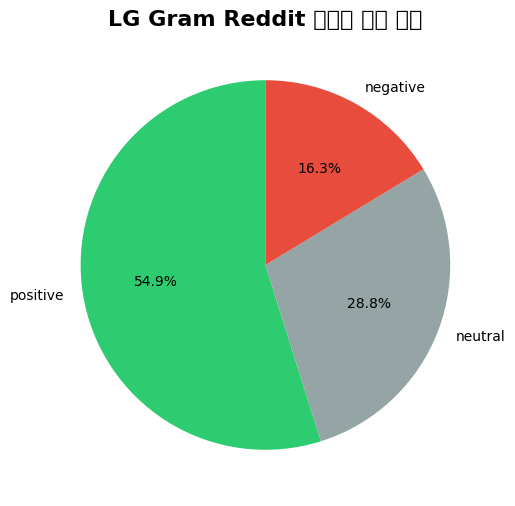

C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tokens, x='빈도', y='토큰', palette='viridis')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:81: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:81: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:81: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:81: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout

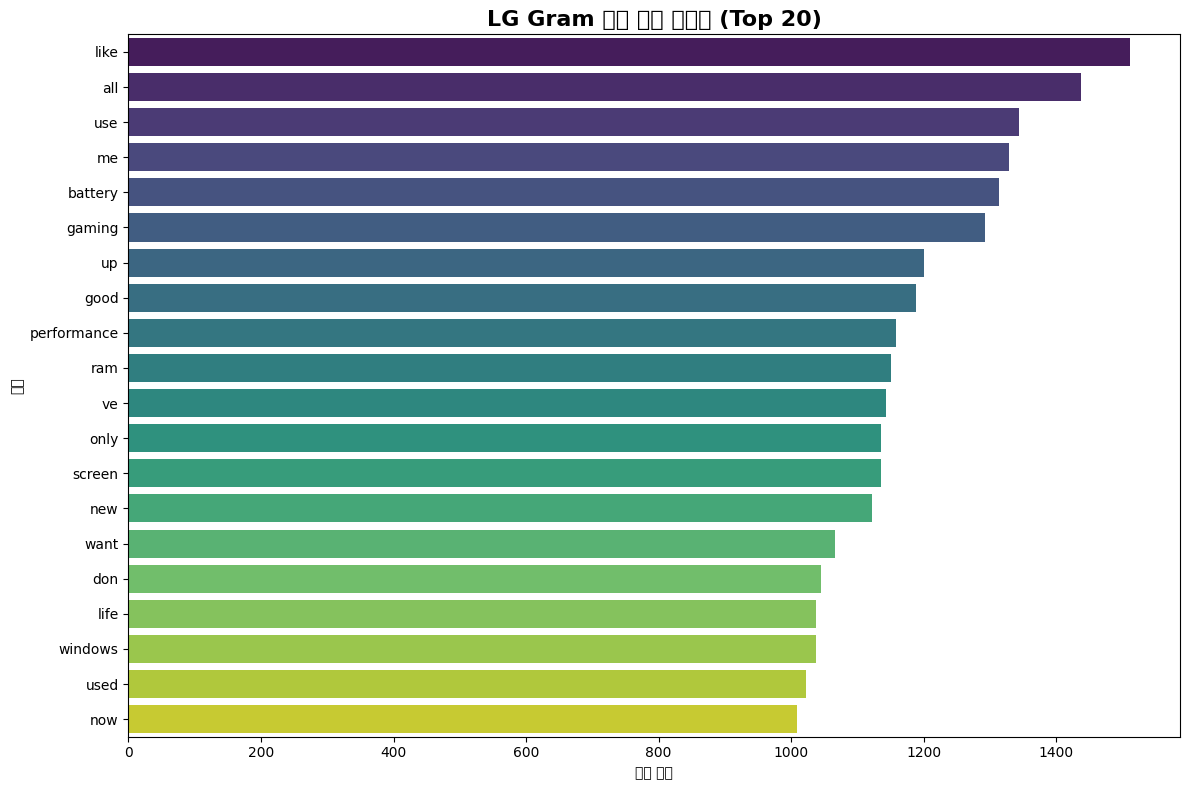

C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:101: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'wordcloud_all.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:101: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'wordcloud_all.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:101: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'wordcloud_all.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:101: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / 'wordcloud_all.png', dpi=300, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:101: UserWarning: G

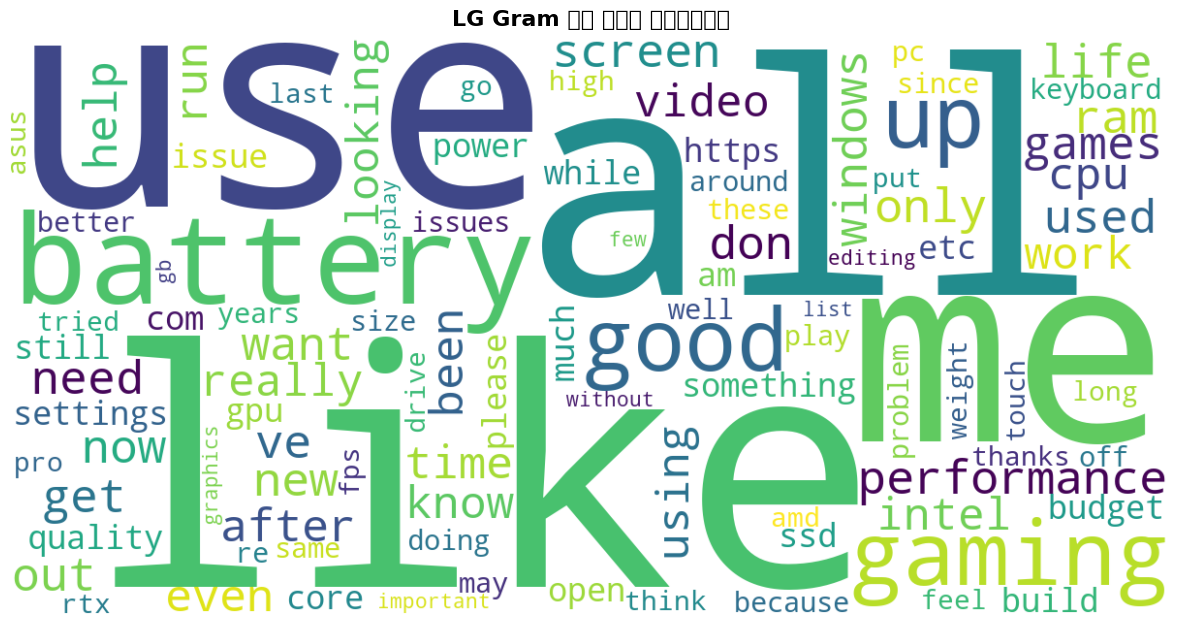

C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:126: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / f'wordcloud_{sentiment_type}.png',
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:126: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / f'wordcloud_{sentiment_type}.png',
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:126: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / f'wordcloud_{sentiment_type}.png',
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:126: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.savefig(IMAGES_DIR / f'wordcloud_{sentiment_type}.png',
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1470368244.py:126: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) De

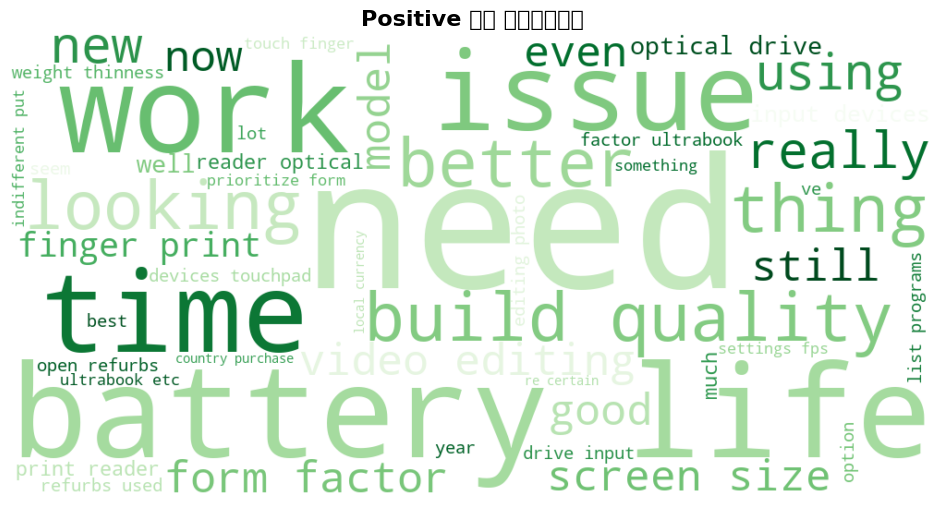

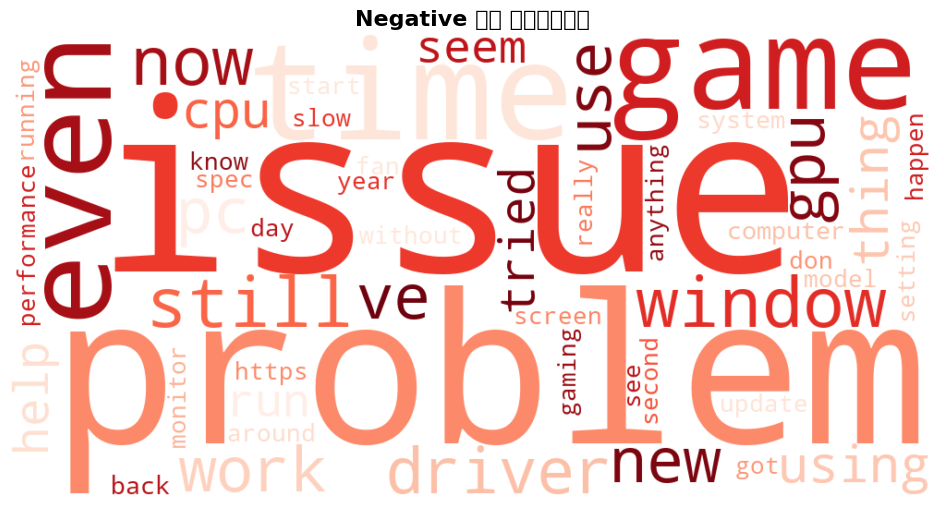

⚠️  시간별 추이 차트 생성 실패: name 'font' is not defined
📊 모든 시각화 완료!


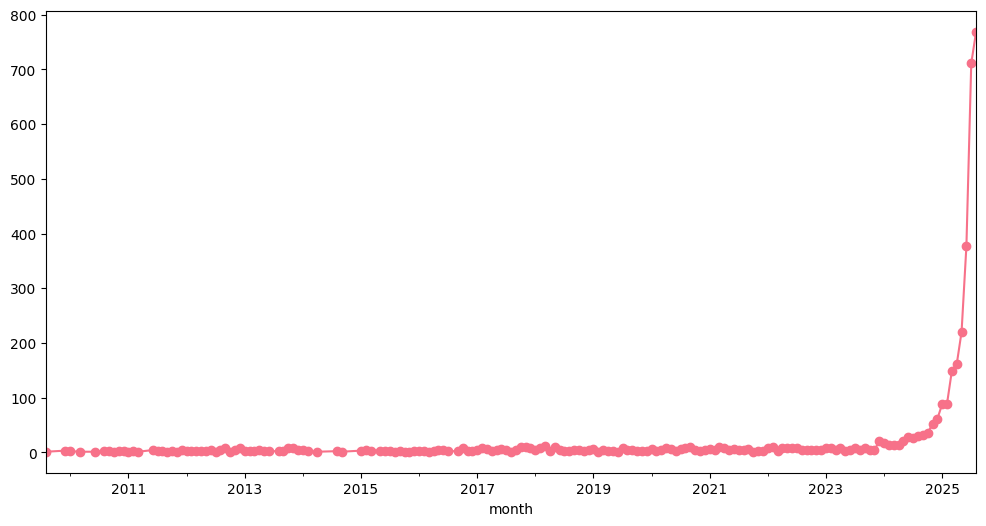

In [11]:
# 7. 데이터 시각화

# 시각화 스타일 설정
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

def create_visualizations():
    """다양한 시각화 생성"""
    if df_raw.empty:
        print("⚠️  시각화할 데이터가 없습니다.")
        return
    
    # 1. 감성 분포 파이 차트
    if 'sentiment' in df_raw.columns:
        plt.figure(figsize=(10, 6))
        sentiment_counts = df_raw['sentiment'].value_counts()
        colors = ['#2ecc71', '#95a5a6', '#e74c3c']  # 초록, 회색, 빨강
        
        plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
                colors=colors, startangle=90)
        plt.title('LG Gram Reddit 포스트 감성 분포', fontsize=16, fontweight='bold')
        plt.savefig(IMAGES_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # 2. 측면별 감성 히트맵
    if 'aspects' in df_raw.columns and 'sentiment' in df_raw.columns:
        # 측면-감성 데이터 준비
        aspect_sentiment_data = []
        for idx, row in df_raw.iterrows():
            if isinstance(row['aspects'], list):
                for aspect in row['aspects']:
                    aspect_sentiment_data.append({
                        'aspect': aspect,
                        'sentiment': row['sentiment']
                    })
        
        if aspect_sentiment_data:
            aspect_df = pd.DataFrame(aspect_sentiment_data)
            
            # 피벗 테이블 생성
            pivot_table = aspect_df.pivot_table(
                index='aspect', 
                columns='sentiment', 
                values='sentiment', 
                aggfunc='count', 
                fill_value=0
            )
            
            if not pivot_table.empty:
                # 비율로 변환
                pivot_ratio = pivot_table.div(pivot_table.sum(axis=1), axis=0)
                
                plt.figure(figsize=(10, 6))
                sns.heatmap(pivot_ratio, annot=True, fmt='.2f', cmap='RdYlGn', 
                           center=0.5, cbar_kws={'label': '감성 비율'})
                plt.title('제품 측면별 감성 분포', fontsize=16, fontweight='bold')
                plt.xlabel('감성')
                plt.ylabel('제품 측면')
                plt.tight_layout()
                plt.savefig(IMAGES_DIR / 'aspect_sentiment_heatmap.png', dpi=300, bbox_inches='tight')
                plt.show()
    
    # 3. 상위 키워드 빈도 차트
    if 'tokens' in df_raw.columns:
        all_tokens = []
        for tokens in df_raw['tokens']:
            if isinstance(tokens, list):
                all_tokens.extend(tokens)
        
        if all_tokens:
            token_freq = Counter(all_tokens)
            top_tokens = pd.DataFrame(token_freq.most_common(20), 
                                    columns=['토큰', '빈도'])
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=top_tokens, x='빈도', y='토큰', palette='viridis')
            plt.title('LG Gram 관련 상위 키워드 (Top 20)', fontsize=16, fontweight='bold')
            plt.xlabel('언급 빈도')
            plt.tight_layout()
            plt.savefig(IMAGES_DIR / 'top_keywords.png', dpi=300, bbox_inches='tight')
            plt.show()
    
    # 4. 워드클라우드 생성
    if 'tokens' in df_raw.columns and all_tokens:
        try:
            # 전체 워드클라우드
            wordcloud_all = WordCloud(
                width=1200, height=600,
                background_color='white',
                colormap='viridis',
                max_words=100,
                relative_scaling=0.5
            ).generate_from_frequencies(dict(token_freq.most_common(100)))
            
            plt.figure(figsize=(15, 8))
            plt.imshow(wordcloud_all, interpolation='bilinear')
            plt.axis('off')
            plt.title('LG Gram 전체 키워드 워드클라우드', fontsize=16, fontweight='bold')
            plt.savefig(IMAGES_DIR / 'wordcloud_all.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            # 감성별 워드클라우드
            for sentiment_type, colormap in [('positive', 'Greens'), ('negative', 'Reds')]:
                sentiment_posts = df_raw[df_raw['sentiment'] == sentiment_type]
                if not sentiment_posts.empty:
                    sentiment_text = ' '.join([
                        ' '.join(tokens) for tokens in sentiment_posts['tokens'] 
                        if isinstance(tokens, list)
                    ])
                    
                    if sentiment_text.strip():
                        wordcloud = WordCloud(
                            width=1000, height=500,
                            background_color='white',
                            colormap=colormap,
                            max_words=50
                        ).generate(sentiment_text)
                        
                        plt.figure(figsize=(12, 6))
                        plt.imshow(wordcloud, interpolation='bilinear')
                        plt.axis('off')
                        plt.title(f'{sentiment_type.title()} 감성 워드클라우드', 
                                fontsize=16, fontweight='bold')
                        plt.savefig(IMAGES_DIR / f'wordcloud_{sentiment_type}.png', 
                                  dpi=300, bbox_inches='tight')
                        plt.show()
        
        except Exception as e:
            print(f"⚠️  워드클라우드 생성 실패: {e}")
    
    # 5. 시간별 포스트 추이 (날짜 데이터가 있는 경우)
    if 'created_date' in df_raw.columns:
        try:
            df_raw['created_date'] = pd.to_datetime(df_raw['created_date'])
            df_raw['month'] = df_raw['created_date'].dt.to_period('M')
            
            monthly_posts = df_raw.groupby('month').size()
            
            if len(monthly_posts) > 1:
                plt.figure(figsize=(12, 6))
                monthly_posts.plot(kind='line', marker='o')
                
                plt.rcParams["font.family"] = font
                plt.title('월별 LG Gram 관련 포스트 수', fontsize=16, fontweight='bold')
                plt.xlabel('월')
                plt.ylabel('포스트 수')
                
                plt.xticks(rotation=45)
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(IMAGES_DIR / 'monthly_posts_trend.png', dpi=300, bbox_inches='tight')
                plt.show()
        except Exception as e:
            print(f"⚠️  시간별 추이 차트 생성 실패: {e}")
    
    print("📊 모든 시각화 완료!")

# 시각화 실행
create_visualizations()

✅ Pros & Cons 분석 결과:
   - 총 Pros 문장: 1129개
   - 총 Cons 문장: 2590개

🟢 상위 Pros 키워드:
   - pro: 1082회
   - https: 232회
   - com: 216회
   - intel: 211회
   - ssd: 206회
   - macbook: 204회
   - core: 176회
   - ram: 170회
   - windows: 162회
   - lenovo: 150회


C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:46: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:46: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:46: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:46: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:46: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:46: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) Dej

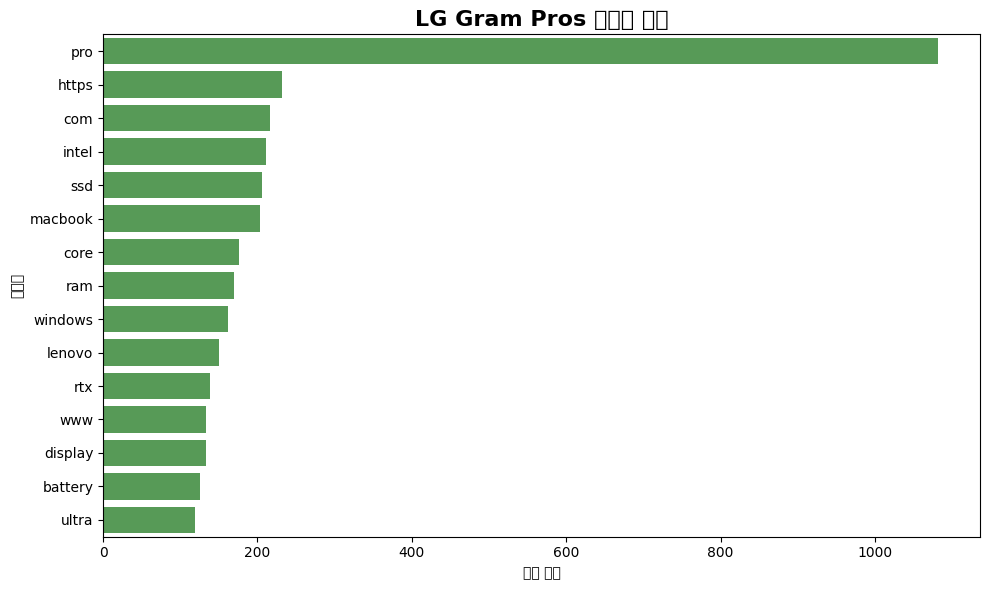

C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:70: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:70: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:70: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:70: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:70: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:70: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) Dej


🔴 상위 Cons 키워드:
   - issue: 1158회
   - problem: 871회
   - issues: 757회
   - all: 481회
   - like: 425회
   - after: 398회
   - windows: 372회
   - been: 344회
   - only: 343회
   - even: 341회


C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49437 (\N

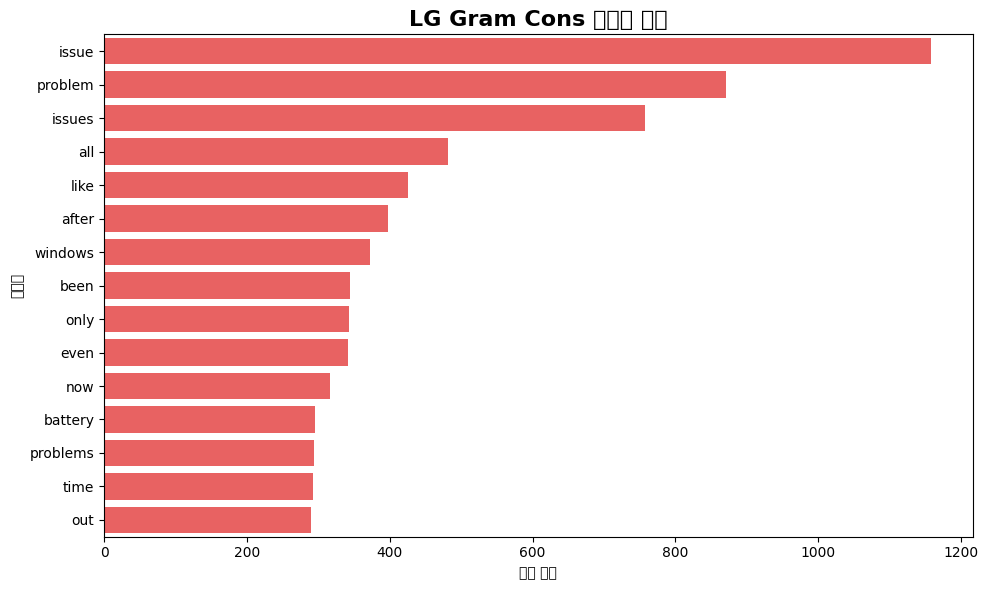

C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_data, x='유형', y='언급 수',
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:92: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:92: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:92: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\3146075855.py:92: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Use

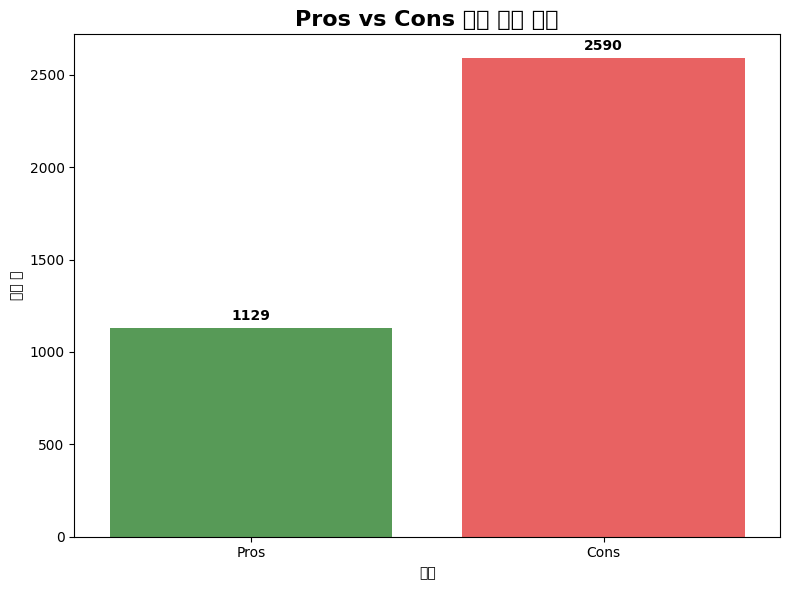


📝 샘플 Pros 문장:
   1. My options seem to be a LG Gram 16, but I do not remember anymore what model was the good one... or ...
   2. Tuning LG Gram Pro 17 for productivity? Lack Snappy feeling..  Any Tips?...
   3. I have LG Gram Pro 17 32GB Ultra 7. Even setting FAN to HIGH, Turned off Energy Saving feature....
   4. Help doing clean install of LG gram Pro 16Z90TS.G.AU89A1...
   5. I just got a LG gram pro 16Z90TS.G.AU89A1...

📝 샘플 Cons 문장:
   1. Hello all. I have a new to me (2023) LG Gram and I really like it. The issue I'm having is I've spen...
   2. I’ve tried uninstalling and reinstalling the battery driver but still no change. Has anyone else run...
   3. I've had an issue with my new 2025 Gram 17, where the autohide for the taskbar doesn't work, the tas...
   4. More importantly, will I have issues using the newest driver from Intel? Will LG or Windows updates ...
   5. LG Gram 14 model number 14T90N Problem finding drivers...

💾 Pros 데이터 저장: data\lg_gram_reddit\analysis\pros_an

In [8]:
# 8. Pros & Cons 상세 분석

def analyze_pros_cons():
    """Pros와 Cons 상세 분석"""
    if df_raw.empty:
        print("⚠️  분석할 데이터가 없습니다.")
        return
    
    # Pros 분석
    all_pros = []
    for pros_list in df_raw['pros_sentences']:
        if isinstance(pros_list, list):
            all_pros.extend(pros_list)
    
    # Cons 분석
    all_cons = []
    for cons_list in df_raw['cons_sentences']:
        if isinstance(cons_list, list):
            all_cons.extend(cons_list)
    
    print(f"✅ Pros & Cons 분석 결과:")
    print(f"   - 총 Pros 문장: {len(all_pros)}개")
    print(f"   - 총 Cons 문장: {len(all_cons)}개")
    
    if all_pros or all_cons:
        # Pros 키워드 분석
        if all_pros:
            pros_text = ' '.join(all_pros).lower()
            pros_words = re.findall(r'\b\w{3,}\b', pros_text)
            pros_words = [word for word in pros_words if word not in ALL_STOPWORDS]
            pros_freq = Counter(pros_words)
            
            print(f"\n🟢 상위 Pros 키워드:")
            for word, count in pros_freq.most_common(10):
                print(f"   - {word}: {count}회")
            
            # Pros 키워드 시각화
            if pros_freq:
                pros_df = pd.DataFrame(pros_freq.most_common(15), 
                                     columns=['키워드', '빈도'])
                
                plt.figure(figsize=(10, 6))
                sns.barplot(data=pros_df, x='빈도', y='키워드', color='green', alpha=0.7)
                plt.title('LG Gram Pros 키워드 분석', fontsize=16, fontweight='bold')
                plt.xlabel('언급 빈도')
                plt.tight_layout()
                plt.savefig(IMAGES_DIR / 'pros_keywords.png', dpi=300, bbox_inches='tight')
                plt.show()
        
        # Cons 키워드 분석
        if all_cons:
            cons_text = ' '.join(all_cons).lower()
            cons_words = re.findall(r'\b\w{3,}\b', cons_text)
            cons_words = [word for word in cons_words if word not in ALL_STOPWORDS]
            cons_freq = Counter(cons_words)
            
            print(f"\n🔴 상위 Cons 키워드:")
            for word, count in cons_freq.most_common(10):
                print(f"   - {word}: {count}회")
            
            # Cons 키워드 시각화
            if cons_freq:
                cons_df = pd.DataFrame(cons_freq.most_common(15), 
                                     columns=['키워드', '빈도'])
                
                plt.figure(figsize=(10, 6))
                sns.barplot(data=cons_df, x='빈도', y='키워드', color='red', alpha=0.7)
                plt.title('LG Gram Cons 키워드 분석', fontsize=16, fontweight='bold')
                plt.xlabel('언급 빈도')
                plt.tight_layout()
                plt.savefig(IMAGES_DIR / 'cons_keywords.png', dpi=300, bbox_inches='tight')
                plt.show()
        
        # Pros vs Cons 비교 차트
        if all_pros and all_cons:
            comparison_data = pd.DataFrame({
                '유형': ['Pros', 'Cons'],
                '언급 수': [len(all_pros), len(all_cons)]
            })
            
            plt.figure(figsize=(8, 6))
            sns.barplot(data=comparison_data, x='유형', y='언급 수', 
                       palette=['green', 'red'], alpha=0.7)
            plt.title('Pros vs Cons 언급 빈도 비교', fontsize=16, fontweight='bold')
            plt.ylabel('언급 수')
            
            # 막대 위에 수치 표시
            for i, v in enumerate(comparison_data['언급 수']):
                plt.text(i, v + max(comparison_data['언급 수']) * 0.01, str(v), 
                        ha='center', va='bottom', fontweight='bold')
            
            plt.tight_layout()
            plt.savefig(IMAGES_DIR / 'pros_cons_comparison.png', dpi=300, bbox_inches='tight')
            plt.show()
        
        # 샘플 Pros & Cons 문장 출력
        print(f"\n📝 샘플 Pros 문장:")
        for i, pros in enumerate(all_pros[:5], 1):
            print(f"   {i}. {pros[:100]}...")
        
        print(f"\n📝 샘플 Cons 문장:")
        for i, cons in enumerate(all_cons[:5], 1):
            print(f"   {i}. {cons[:100]}...")
        
        # Pros/Cons 데이터 저장
        if all_pros:
            pros_df_save = pd.DataFrame({'pros_sentence': all_pros})
            pros_df_save.to_csv(PROS_FILE, index=False, encoding='utf-8-sig')
            print(f"\n💾 Pros 데이터 저장: {PROS_FILE}")
        
        if all_cons:
            cons_df_save = pd.DataFrame({'cons_sentence': all_cons})
            cons_df_save.to_csv(CONS_FILE, index=False, encoding='utf-8-sig')
            print(f"💾 Cons 데이터 저장: {CONS_FILE}")
    
    else:
        print("⚠️  추출된 Pros/Cons 문장이 없습니다.")

# Pros & Cons 분석 실행
analyze_pros_cons()

🔗 바이그램 분석 시작...
✅ 바이그램 분석 완료!
   - 총 바이그램 수: 302131
   - 상위 10개 바이그램:
      1. 'battery life': 805회
      2. 'build quality': 507회
      3. 'video editing': 469회
      4. 'form factor': 428회
      5. 'screen size': 418회
      6. 'finger print': 405회
      7. 'optical drive': 405회
      8. 'https www': 404회
      9. 'input devices': 402회
      10. 'reader optical': 401회


C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1652635143.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bigrams.head(20), x='frequency', y='bigram', palette='plasma')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1652635143.py:53: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1652635143.py:53: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1652635143.py:53: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6520\1652635143.py:53: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  

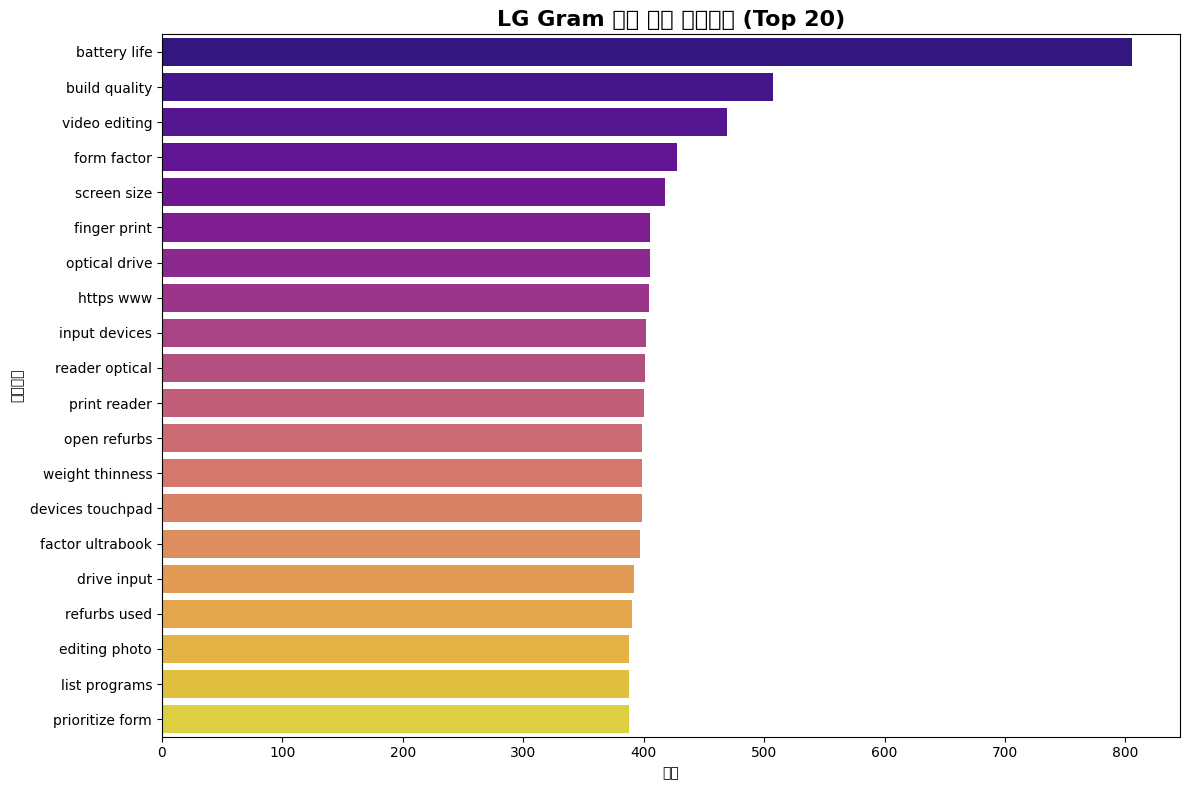


🔍 공기어 분석...
   'performance'와 함께 나타나는 단어들:
      - gaming: 771회
      - use: 706회
      - battery: 666회
      - good: 659회
      - games: 639회
   'battery'와 함께 나타나는 단어들:
      - life: 959회
      - use: 765회
      - good: 742회
      - gaming: 733회
      - screen: 719회
   'weight'와 함께 나타나는 단어들:
      - battery: 558회
      - life: 529회
      - screen: 520회
      - gaming: 519회
      - size: 500회
   'heat'와 함께 나타나는 단어들:
      - like: 134회
      - up: 111회
      - all: 110회
      - ve: 103회
      - use: 101회
   'keyboard'와 함께 나타나는 단어들:
      - battery: 589회
      - screen: 570회
      - gaming: 569회
      - use: 542회
      - good: 539회
   'display'와 함께 나타나는 단어들:
      - ram: 339회
      - all: 304회
      - use: 296회
      - battery: 293회
      - windows: 289회
   'price'와 함께 나타나는 단어들:
      - gaming: 296회
      - use: 272회
      - good: 270회
      - like: 264회
      - all: 262회

📊 토큰 길이 분석:
   - 평균 토큰 길이: 5.9자
   - 최대 토큰 길이: 596자
   - 가장 흔한 토큰 길이: (4, 80104)자

💾 바이그램 분석 결과 저장: data\lg_gram_re

In [9]:
# 9. 바이그램 분석 및 고급 텍스트 분석

from itertools import combinations

def generate_bigrams(tokens):
    """토큰 리스트에서 바이그램 생성"""
    if len(tokens) < 2:
        return []
    return [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]

def analyze_bigrams_and_patterns():
    """바이그램 및 텍스트 패턴 분석"""
    if df_raw.empty or 'tokens' not in df_raw.columns:
        print("⚠️  분석할 토큰 데이터가 없습니다.")
        return
    
    print("🔗 바이그램 분석 시작...")
    
    # 모든 바이그램 수집
    all_bigrams = []
    for tokens in df_raw['tokens']:
        if isinstance(tokens, list) and len(tokens) > 1:
            bigrams = generate_bigrams(tokens)
            all_bigrams.extend(bigrams)
    
    if not all_bigrams:
        print("⚠️  생성된 바이그램이 없습니다.")
        return
    
    # 바이그램 빈도 분석
    bigram_freq = Counter(all_bigrams)
    bigram_strings = [f"{gram[0]} {gram[1]}" for gram in bigram_freq.keys()]
    bigram_counts = list(bigram_freq.values())
    
    # 상위 바이그램 데이터프레임
    top_bigrams = pd.DataFrame({
        'bigram': [f"{gram[0]} {gram[1]}" for gram, _ in bigram_freq.most_common(30)],
        'frequency': [count for _, count in bigram_freq.most_common(30)]
    })
    
    print(f"✅ 바이그램 분석 완료!")
    print(f"   - 총 바이그램 수: {len(bigram_freq)}")
    print(f"   - 상위 10개 바이그램:")
    for i, (bigram, freq) in enumerate(bigram_freq.most_common(10), 1):
        print(f"      {i}. '{bigram[0]} {bigram[1]}': {freq}회")
    
    # 바이그램 시각화
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_bigrams.head(20), x='frequency', y='bigram', palette='plasma')
    plt.title('LG Gram 관련 상위 바이그램 (Top 20)', fontsize=16, fontweight='bold')
    plt.xlabel('빈도')
    plt.ylabel('바이그램')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'top_bigrams.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 공기어(Co-occurrence) 분석
    print(f"\n🔍 공기어 분석...")
    
    # 주요 키워드와 함께 나타나는 단어들 분석
    key_terms = ['performance', 'battery', 'weight', 'heat', 'keyboard', 'display', 'price']
    
    cooccurrence_results = {}
    for term in key_terms:
        cooccur_words = []
        for tokens in df_raw['tokens']:
            if isinstance(tokens, list) and term in tokens:
                cooccur_words.extend([word for word in tokens if word != term])
        
        if cooccur_words:
            cooccur_freq = Counter(cooccur_words)
            cooccurrence_results[term] = cooccur_freq.most_common(5)
    
    # 공기어 결과 출력
    for term, cooccur_list in cooccurrence_results.items():
        if cooccur_list:
            print(f"   '{term}'와 함께 나타나는 단어들:")
            for word, freq in cooccur_list:
                print(f"      - {word}: {freq}회")
    
    # N-gram 길이별 통계
    print(f"\n📊 토큰 길이 분석:")
    token_lengths = []
    for tokens in df_raw['tokens']:
        if isinstance(tokens, list):
            token_lengths.extend([len(token) for token in tokens])
    
    if token_lengths:
        length_freq = Counter(token_lengths)
        print(f"   - 평균 토큰 길이: {np.mean(token_lengths):.1f}자")
        print(f"   - 최대 토큰 길이: {max(token_lengths)}자")
        print(f"   - 가장 흔한 토큰 길이: {length_freq.most_common(1)[0]}자")
    
    # 데이터 저장
    if not top_bigrams.empty:
        top_bigrams.to_csv(ANALYSIS_DIR / 'bigram_analysis.csv', 
                          index=False, encoding='utf-8-sig')
        print(f"\n💾 바이그램 분석 결과 저장: {ANALYSIS_DIR / 'bigram_analysis.csv'}")
    
    return top_bigrams, cooccurrence_results

# 바이그램 분석 실행
bigram_results, cooccur_results = analyze_bigrams_and_patterns()

In [10]:
# 10. 최종 결과 요약 및 인사이트 도출

def generate_final_report():
    """최종 분석 보고서 생성"""
    if df_raw.empty:
        print("⚠️  보고서를 생성할 데이터가 없습니다.")
        return
    
    print("📋 LG Gram Reddit 분석 최종 보고서")
    print("=" * 50)
    
    # 1. 기본 통계
    print(f"\n📊 1. 데이터 수집 현황")
    print(f"   • 총 수집 포스트: {len(df_raw):,}개")
    print(f"   • 분석 대상 서브레딧: {df_raw['subreddit'].nunique()}개")
    print(f"   • 수집 기간: {df_raw['created_date'].min().strftime('%Y-%m-%d')} ~ {df_raw['created_date'].max().strftime('%Y-%m-%d')}")
    print(f"   • 평균 포스트 점수: {df_raw['score'].mean():.1f}점")
    print(f"   • 평균 댓글 수: {df_raw['num_comments'].mean():.1f}개")
    
    # 2. 감성 분석 결과
    if 'sentiment' in df_raw.columns:
        print(f"\n🎭 2. 감성 분석 결과")
        sentiment_counts = df_raw['sentiment'].value_counts()
        total_posts = len(df_raw)
        
        for sentiment, count in sentiment_counts.items():
            percentage = (count / total_posts) * 100
            emoji = "😊" if sentiment == "positive" else "😐" if sentiment == "neutral" else "😞"
            print(f"   {emoji} {sentiment.title()}: {count:,}개 ({percentage:.1f}%)")
        
        # 감성 점수 통계
        if 'polarity_score' in df_raw.columns:
            print(f"   • 평균 감성 점수: {df_raw['polarity_score'].mean():.3f}")
            print(f"   • 감성 점수 범위: {df_raw['polarity_score'].min():.3f} ~ {df_raw['polarity_score'].max():.3f}")
    
    # 3. 주요 토픽 및 키워드
    if 'tokens' in df_raw.columns:
        print(f"\n🔍 3. 주요 토픽 및 키워드")
        all_tokens = []
        for tokens in df_raw['tokens']:
            if isinstance(tokens, list):
                all_tokens.extend(tokens)
        
        if all_tokens:
            token_freq = Counter(all_tokens)
            print(f"   • 총 유니크 키워드: {len(token_freq):,}개")
            print(f"   • 상위 10개 키워드:")
            for i, (word, count) in enumerate(token_freq.most_common(10), 1):
                print(f"      {i:2d}. {word}: {count:,}회")
    
    # 4. 제품 측면 분석
    if 'aspects' in df_raw.columns:
        print(f"\n🎯 4. 제품 측면 분석")
        all_aspects = []
        for aspects in df_raw['aspects']:
            if isinstance(aspects, list):
                all_aspects.extend(aspects)
        
        if all_aspects:
            aspect_freq = Counter(all_aspects)
            print(f"   • 주요 논의 측면:")
            for aspect, count in aspect_freq.most_common(8):
                print(f"      • {aspect}: {count:,}회 언급")
    
    # 5. Pros & Cons 요약
    total_pros = sum(len(pros) if isinstance(pros, list) else 0 for pros in df_raw['pros_sentences'])
    total_cons = sum(len(cons) if isinstance(cons, list) else 0 for cons in df_raw['cons_sentences'])
    
    print(f"\n⚖️  5. Pros & Cons 분석")
    print(f"   • 총 장점 언급: {total_pros:,}건")
    print(f"   • 총 단점 언급: {total_cons:,}건")
    
    if total_pros > 0 and total_cons > 0:
        pros_ratio = total_pros / (total_pros + total_cons) * 100
        print(f"   • 장점/단점 비율: {pros_ratio:.1f}% / {100-pros_ratio:.1f}%")
    
    # 6. 인사이트 및 권장사항
    print(f"\n💡 6. 주요 인사이트")
    
    # 감성 기반 인사이트
    if 'sentiment' in df_raw.columns:
        positive_ratio = (df_raw['sentiment'] == 'positive').sum() / len(df_raw) * 100
        if positive_ratio > 50:
            print(f"   ✅ 전반적으로 긍정적인 반응 ({positive_ratio:.1f}%)")
        elif positive_ratio < 30:
            print(f"   ⚠️  부정적인 반응이 우세함 ({100-positive_ratio:.1f}%)")
        else:
            print(f"   🔄 중립적인 반응이 대부분")
    
    # 가장 많이 논의되는 측면
    if all_aspects:
        top_aspect = aspect_freq.most_common(1)[0][0]
        print(f"   🎯 가장 많이 논의되는 측면: '{top_aspect}'")
    
    # 바이그램 기반 인사이트
    if 'bigram_results' in globals() and not bigram_results.empty:
        top_bigram = bigram_results.iloc[0]['bigram']
        print(f"   🔗 가장 빈번한 키워드 조합: '{top_bigram}'")
    
    # 7. 파일 저장 정보
    print(f"\n💾 7. 저장된 파일")
    print(f"   • 원본 데이터: {RAW_DATA_FILE}")
    print(f"   • 처리된 데이터: {PROCESSED_DATA_FILE}")
    print(f"   • 시각화 이미지: {IMAGES_DIR}")
    print(f"   • 분석 결과: {ANALYSIS_DIR}")
    
    # 최종 데이터 저장
    df_raw.to_csv(PROCESSED_DATA_FILE, index=False, encoding='utf-8-sig')
    
    # 요약 통계를 JSON으로 저장
    summary_stats = {
        'total_posts': len(df_raw),
        'date_range': {
            'start': df_raw['created_date'].min().isoformat(),
            'end': df_raw['created_date'].max().isoformat()
        },
        'sentiment_distribution': df_raw['sentiment'].value_counts().to_dict() if 'sentiment' in df_raw.columns else {},
        'top_keywords': dict(token_freq.most_common(20)) if 'token_freq' in locals() else {},
        'aspect_frequency': dict(aspect_freq.most_common(10)) if 'aspect_freq' in locals() else {},
        'pros_cons_count': {
            'pros': total_pros,
            'cons': total_cons
        }
    }
    
    with open(ANALYSIS_DIR / 'summary_stats.json', 'w', encoding='utf-8') as f:
        json.dump(summary_stats, f, ensure_ascii=False, indent=2)
    
    print(f"   • 요약 통계: {ANALYSIS_DIR / 'summary_stats.json'}")
    
    print(f"\n🎉 분석 완료! 모든 결과가 저장되었습니다.")
    
    return summary_stats

# 최종 보고서 생성
final_report = generate_final_report()

📋 LG Gram Reddit 분석 최종 보고서

📊 1. 데이터 수집 현황
   • 총 수집 포스트: 3,546개
   • 분석 대상 서브레딧: 8개
   • 수집 기간: 2009-08-26 ~ 2025-08-18
   • 평균 포스트 점수: 33.1점
   • 평균 댓글 수: 17.3개

🎭 2. 감성 분석 결과
   😊 Positive: 1,945개 (54.9%)
   😐 Neutral: 1,022개 (28.8%)
   😞 Negative: 579개 (16.3%)
   • 평균 감성 점수: 0.161
   • 감성 점수 범위: -0.900 ~ 1.269

🔍 3. 주요 토픽 및 키워드
   • 총 유니크 키워드: 36,562개
   • 상위 10개 키워드:
       1. like: 1,511회
       2. all: 1,437회
       3. use: 1,344회
       4. me: 1,328회
       5. battery: 1,314회
       6. gaming: 1,293회
       7. up: 1,201회
       8. good: 1,188회
       9. performance: 1,158회
      10. ram: 1,151회

🎯 4. 제품 측면 분석
   • 주요 논의 측면:
      • performance: 2,622회 언급
      • design: 2,613회 언급
      • battery: 2,110회 언급
      • display: 1,785회 언급
      • thermals: 1,779회 언급
      • ports: 1,591회 언급
      • price: 1,499회 언급
      • weight: 1,418회 언급

⚖️  5. Pros & Cons 분석
   • 총 장점 언급: 1,129건
   • 총 단점 언급: 2,590건
   • 장점/단점 비율: 30.4% / 69.6%

💡 6. 주요 인사이트
   ✅ 전반적으로 긍정적인 반응 (54.9%)
   🎯 가장 많이

## 🚀 추가 분석 및 활용 방안

### 📈 심화 분석 아이디어

1. **시계열 분석**
   - 월별/주별 감성 변화 추이 분석
   - 신제품 출시 시기와 감성 변화 상관관계 분석

2. **경쟁사 비교 분석**
   - 다른 브랜드(Dell XPS, MacBook Air 등)와 비교
   - 브랜드별 언급량 및 감성 차이 분석

3. **사용자 프로파일링**
   - 활발한 사용자들의 댓글 패턴 분석
   - 전문가 vs 일반 사용자 의견 구분

4. **예측 모델링**
   - 감성 예측 모델 구축
   - 제품 개선점 우선순위 예측

### 🛠️ 기술적 개선 방안

1. **고급 NLP 기법 적용**
   - BERT, KoBERT를 활용한 더 정확한 감성 분석
   - Named Entity Recognition (NER)로 제품명/모델명 정확히 추출

2. **실시간 모니터링**
   - 스케줄러를 통한 자동 데이터 수집
   - 대시보드 구축으로 실시간 모니터링

3. **다중 플랫폼 확장**
   - YouTube 댓글, 블로그 리뷰 등 다양한 소스 통합
   - 소셜미디어 (Twitter, Instagram) 데이터 추가

### 💼 비즈니스 활용 방안

1. **제품 개발팀**
   - 주요 불만사항을 제품 개선 로드맵에 반영
   - 신제품 기획 시 사용자 니즈 참고

2. **마케팅팀**
   - 긍정적 키워드를 마케팅 메시지에 활용
   - 타겟 고객층별 맞춤 메시지 개발

3. **고객지원팀**
   - 자주 제기되는 문제점에 대한 FAQ 업데이트
   - 고객 상담 시 참고 자료로 활용

### 📚 참고 자료

- [Reddit API 문서](https://www.reddit.com/dev/api/)
- [PRAW (Python Reddit API Wrapper) 가이드](https://praw.readthedocs.io/)
- [KoNLPy 한국어 자연어 처리](https://konlpy.org/)
- [TextBlob 감성 분석](https://textblob.readthedocs.io/)

### ⚠️ 주의사항

1. **데이터 수집 윤리**
   - Reddit 이용약관 준수
   - 개인정보 보호 고려
   - API Rate Limit 준수

2. **분석 결과 해석**
   - 샘플 편향 가능성 고려
   - 통계적 유의성 검증 필요
   - 정성적 분석과 병행 권장

3. **데이터 품질 관리**
   - 스팸/봇 포스트 필터링
   - 중복 데이터 정기적 정리
   - 데이터 검증 프로세스 구축

In [13]:
# 11. Pros 분석 파일 한글 번역

def translate_pros_to_korean():
    """Pros 분석 파일을 한글로 번역하여 새 파일 생성"""
    
    # 영어-한국어 번역 사전 (LG Gram 관련 주요 용어)
    translation_dict = {
        # 제품 관련
        'LG Gram': 'LG 그램',
        'LG gram': 'LG 그램',
        'laptop': '노트북',
        'laptop.': '노트북.',
        'laptops': '노트북들',
        'notebook': '노트북',
        'computer': '컴퓨터',
        'device': '기기',
        'machine': '기계',
        
        # 성능 관련
        'performance': '성능',
        'speed': '속도',
        'fast': '빠른',
        'slow': '느린',
        'powerful': '강력한',
        'efficient': '효율적인',
        'smooth': '부드러운',
        'responsive': '반응성 좋은',
        
        # 배터리 관련
        'battery': '배터리',
        'battery life': '배터리 수명',
        'power': '전력',
        'charging': '충전',
        'charge': '충전',
        
        # 화면 관련
        'screen': '화면',
        'display': '디스플레이',
        'monitor': '모니터',
        'resolution': '해상도',
        'brightness': '밝기',
        'color': '색상',
        'touch': '터치',
        'touchscreen': '터치스크린',
        
        # 무게/디자인 관련
        'weight': '무게',
        'light': '가벼운',
        'lightweight': '가벼운',
        'portable': '휴대용',
        'thin': '얇은',
        'slim': '슬림한',
        'design': '디자인',
        'build quality': '제작 품질',
        'form factor': '폼 팩터',
        
        # 키보드/입력 관련
        'keyboard': '키보드',
        'typing': '타이핑',
        'keys': '키',
        'trackpad': '트랙패드',
        'mouse': '마우스',
        
        # 메모리/저장장치
        'RAM': 'RAM',
        'memory': '메모리',
        'storage': '저장장치',
        'SSD': 'SSD',
        'hard drive': '하드드라이브',
        
        # 연결/포트
        'USB': 'USB',
        'port': '포트',
        'ports': '포트들',
        'HDMI': 'HDMI',
        'connection': '연결',
        'connectivity': '연결성',
        
        # 일반적인 긍정 표현
        'good': '좋은',
        'great': '훌륭한',
        'excellent': '뛰어난',
        'amazing': '놀라운',
        'awesome': '멋진',
        'perfect': '완벽한',
        'best': '최고의',
        'better': '더 나은',
        'love': '좋아하는',
        'like': '마음에 드는',
        'recommend': '추천하는',
        'impressed': '감명받은',
        'satisfied': '만족하는',
        'happy': '만족하는',
        
        # 사용 관련
        'use': '사용',
        'using': '사용하는',
        'user': '사용자',
        'work': '작업',
        'working': '작업하는',
        'productivity': '생산성',
        'office': '사무',
        'business': '비즈니스',
        'gaming': '게임',
        'editing': '편집',
        'video editing': '비디오 편집',
        'photo editing': '사진 편집',
        
        # 기타 유용한 표현
        'pros': '장점',
        'advantages': '장점들',
        'benefits': '이점들',
        'features': '기능들',
        'option': '옵션',
        'choice': '선택',
        'model': '모델',
        'version': '버전',
        'upgrade': '업그레이드',
        'quality': '품질',
        'price': '가격',
        'value': '가치',
        'money': '돈',
        'budget': '예산',
        
        # 문장 연결어
        'and': '그리고',
        'but': '하지만',
        'or': '또는',
        'with': '~와 함께',
        'for': '~을 위한',
        'to': '~에',
        'the': '',  # 관사는 생략
        'a': '',    # 관사는 생략
        'an': '',   # 관사는 생략
        
        # 시간 관련
        'years': '년',
        'months': '개월',
        'days': '일',
        'hours': '시간',
        'minutes': '분',
        'daily': '매일',
        'new': '새로운',
        'old': '오래된',
        
        # 문제 관련 (긍정적 맥락에서)
        'issue': '문제',
        'problem': '문제',
        'solution': '해결책',
        'fix': '수정',
        'help': '도움',
        'support': '지원',
        'service': '서비스'
    }
    
    def simple_translate(text):
        """간단한 사전 기반 번역"""
        if pd.isna(text) or text == '':
            return text
            
        # 텍스트를 소문자로 변환하여 번역 사전과 매칭
        translated_text = str(text)
        
        # 길이가 긴 키워드부터 우선 번역 (부분 매칭 방지)
        for eng_word, kor_word in sorted(translation_dict.items(), key=lambda x: len(x[0]), reverse=True):
            # 대소문자 구분 없이 단어 단위로 번역
            import re
            pattern = r'\b' + re.escape(eng_word) + r'\b'
            translated_text = re.sub(pattern, kor_word, translated_text, flags=re.IGNORECASE)
        
        return translated_text.strip()
    
    try:
        # 원본 파일 읽기
        pros_file_path = ANALYSIS_DIR / 'pros_analysis.csv'
        if not pros_file_path.exists():
            print("⚠️ pros_analysis.csv 파일을 찾을 수 없습니다.")
            return
        
        print("📖 Pros 분석 파일 읽는 중...")
        df_pros = pd.read_csv(pros_file_path, encoding='utf-8-sig')
        
        print(f"📊 번역할 문장 수: {len(df_pros):,}개")
        
        # 번역 실행
        print("🔄 번역 시작...")
        tqdm.pandas(desc="번역 진행")
        
        df_pros['korean_pros'] = df_pros['pros_sentence'].progress_apply(simple_translate)
        
        # 번역 결과 데이터프레임 생성
        df_translated = pd.DataFrame({
            'original_pros': df_pros['pros_sentence'],
            'korean_pros': df_pros['korean_pros']
        })
        
        # 새 파일로 저장
        output_file = ANALYSIS_DIR / 'Pros_LG.csv'
        df_translated.to_csv(output_file, index=False, encoding='utf-8-sig')
        
        print(f"✅ 번역 완료!")
        print(f"📁 저장 위치: {output_file}")
        print(f"📊 번역된 문장 수: {len(df_translated):,}개")
        
        # 번역 통계
        original_words = df_translated['original_pros'].str.len().sum()
        translated_words = df_translated['korean_pros'].str.len().sum()
        print(f"📈 원문 총 문자 수: {original_words:,}")
        print(f"📈 번역문 총 문자 수: {translated_words:,}")
        
        # 샘플 결과 출력
        print(f"\n📝 번역 샘플 (처음 5개):")
        for i, row in df_translated.head(5).iterrows():
            print(f"\n{i+1}. 원문:")
            print(f"   {row['original_pros'][:150]}...")
            print(f"   번역:")
            print(f"   {row['korean_pros'][:150]}...")
        
        # 번역 품질 체크 (한글이 포함된 비율)
        korean_count = df_translated['korean_pros'].str.contains('[가-힣]', regex=True).sum()
        korean_ratio = korean_count / len(df_translated) * 100
        print(f"\n📊 번역 품질:")
        print(f"   - 한글이 포함된 문장: {korean_count:,}개 ({korean_ratio:.1f}%)")
        
        return df_translated
        
    except Exception as e:
        print(f"❌ 번역 중 오류 발생: {e}")
        return None

# 번역 실행
print("🌐 LG Gram Pros 분석 한글 번역 시작...")
translated_pros = translate_pros_to_korean()

🌐 LG Gram Pros 분석 한글 번역 시작...
📖 Pros 분석 파일 읽는 중...
📊 번역할 문장 수: 1,129개
🔄 번역 시작...


번역 진행:  31%|███       | 347/1129 [00:00<00:00, 1205.34it/s]

번역 진행: 100%|██████████| 1129/1129 [00:00<00:00, 1228.34it/s]

✅ 번역 완료!
📁 저장 위치: data\lg_gram_reddit\analysis\Pros_LG.csv
📊 번역된 문장 수: 1,129개
📈 원문 총 문자 수: 269,744
📈 번역문 총 문자 수: 255,110

📝 번역 샘플 (처음 5개):

1. 원문:
   My options seem to be a LG Gram 16, but I do not remember anymore what model was the good one... or the yoga pro 9i gen10 aura edition. (was checking ...
   번역:
   My options seem ~에 be  LG 그램 16, 하지만 I do not remember anymore what 모델 was  좋은 one... 또는  yoga pro 9i gen10 aura edition. (was checking this https://w...

2. 원문:
   Tuning LG Gram Pro 17 for productivity? Lack Snappy feeling..  Any Tips?...
   번역:
   Tuning LG 그램 Pro 17 ~을 위한 생산성? Lack Snappy feeling..  Any Tips?...

3. 원문:
   I have LG Gram Pro 17 32GB Ultra 7. Even setting FAN to HIGH, Turned off Energy Saving feature....
   번역:
   I have LG 그램 Pro 17 32GB Ultra 7. Even setting FAN ~에 HIGH, Turned off Energy Saving feature....

4. 원문:
   Help doing clean install of LG gram Pro 16Z90TS.G.AU89A1...
   번역:
   도움 doing clean install of LG 그램 Pro 16Z90TS.G.AU89A1...

5. 원문:
   I j